# Lab 11: Root Finding

## Examples (by instructor)

In this lab you will practice the root-finding tools from Chapter 16:

| Task | Tool | Key syntax |
|------|------|-----------|
| Polynomial roots (all at once) | `np.roots` | `np.roots([c0, c1, ..., cn])` |
| Single equation, bracketed | `scipy.optimize.brentq` | `brentq(f, a, b)` |
| System of nonlinear equations | `scipy.optimize.fsolve` | `fsolve(F, x0)` |

**Workflow for every root-finding problem:**
1. Rewrite the equation as $f(x) = 0$
2. **Plot** $f(x)$ to count roots and find brackets
3. Choose your tool and solve
4. **Verify** by checking $f(x^*) \approx 0$

### Example 1: van der Waals Molar Volume (`brentq`)

The van der Waals equation of state for CO₂ at $T = 310$ K, $P = 70$ bar:

$$\left(P + \frac{a}{V^2}\right)(V - b) = RT \quad \Longrightarrow \quad f(V) = \left(P + \frac{a}{V^2}\right)(V - b) - RT = 0$$

Constants for CO₂: $a = 3.658$ L²·bar/mol², $b = 0.04286$ L/mol, $R = 0.08314$ L·bar/(mol·K).

**Step 1:** Always plot $f(V)$ first to locate the bracket. **Step 2:** Call `brentq` with the bracket.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, fsolve

R = 0.08314   # L·bar / (mol·K)
a = 3.658     # L²·bar / mol²   (CO2)
b = 0.04286   # L/mol           (CO2)
T = 310.0     # K
P = 70.0      # bar



In [ ]:
# Step 2: solve with brentq


### Example 2: Intersection of Two Curves (`fsolve`)

Find where the parabola $y = x^2$ meets the line $y = 2 - x$. Rewrite as a system $\mathbf{F}(\mathbf{x}) = \mathbf{0}$:

$$\begin{cases} y - x^2 = 0 \\ y + x - 2 = 0 \end{cases}$$

There are two solutions — use different initial guesses to find each. **Always print residuals** to verify `fsolve` converged to a true solution.

---

## Warm-Up: Syntax Practice

Short exercises to get comfortable with the root-finding tools before the main problems.

**Exercise 1 — `brentq`: find the root of a simple function.**

Find the root of $f(x) = e^x - 3x$ near $x = 1$ using `brentq`.

1. Plot $f(x)$ on $[-1, 3]$ to identify a bracket where the function changes sign.
2. Call `brentq(f, a, b)` with your bracket.
3. Print the root and verify $f(x^*) \approx 0$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, fsolve

def f(x):
    return ___

x_plot = np.linspace(-1, 3, 300)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(___, ___, 'steelblue', linewidth=2)
ax.axhline(0, color='k', linewidth=1)
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title(r'$f(x) = e^x - 3x$')
plt.tight_layout(); plt.show()

root = ___   # f(1) < 0, f(2) > 0

print(f"Root: x* = {root:.6f}")
print(f"f(x*) = {f(root):.2e}")

**Exercise 2 — `np.roots`: all roots of a polynomial.**

Find all roots of the cubic $p(V) = V^3 - 6V^2 + 11V - 6$ using `np.roots`.

Recall: pass coefficients from **highest to lowest degree** — `np.roots([1, -6, 11, -6])`.

Print each root and verify $p(V^*) \approx 0$ for each real root.

In [ ]:
coeffs = [1, -6, 11, -6]   # coefficients of p(V) = V^3 - 6V^2 + 11V - 6

roots = ___
print("All roots:", roots)

for r in roots:
    if np.isreal(r):
        print(f"  V* = {r.real:.4f},  p(V*) = {np.polyval(___, r.real):.2e}")

**Exercise 3 — `fsolve`: two nonlinear equations.**

Find the intersection(s) of $y = x^2$ and $y = 2 - x$ by solving:

$$\begin{cases} y - x^2 = 0 \\ y + x - 2 = 0 \end{cases}$$

Use `fsolve` with two different initial guesses to find both solutions. Always print the residuals to verify.

In [ ]:
def equations(vars):
    x, y = vars
    eq1 = ___      # y - x^2
    eq2 = ___      # y + x - 2
    return [___, ___]

sol1 = fsolve(___, x0=[-2.0, 3.0])   # guess near one solution
sol2 = fsolve(___, x0=[___, ___])   # guess near the other (1.0, 1.0)

print(f"Solution 1: x = {sol1[0]:.6f},  y = {sol1[1]:.6f}   residuals: {equations(sol1)}")
print(f"Solution 2: x = {sol2[0]:.6f},  y = {sol2[1]:.6f}   residuals: {equations(sol2)}")

---

## Practice Problems (by students)

### Problem 1: Reaction Equilibrium — Effect of Temperature

Consider the gas-phase reaction $\text{A} \rightleftharpoons 2\,\text{B}$ at $P = 3$ atm. The equilibrium constant varies with temperature as:

$$K_{eq}(T) = \exp\!\left(4.0 - \frac{3000}{T}\right), \qquad T \text{ in K}$$

Starting from pure A, the mole balance gives:

| Species | Initial | Change | At equilibrium |
|---------|---------|--------|----------------|
| A | 1 | $-X$ | $1 - X$ |
| B | 0 | $+2X$ | $2X$ |
| **Total** | 1 | $+X$ | $1 + X$ |

So the mole fractions are $y_A = \dfrac{1-X}{1+X}$ and $y_B = \dfrac{2X}{1+X}$, and the equilibrium condition is:

$$f(X_e) = \frac{4 X_e^2}{1 - X_e^2} \cdot P - K_{eq}(T) = 0$$

**(a)** At $T = 800$ K, plot $f(X_e)$ on $[0.01, 0.99]$, then use `brentq` to find the equilibrium conversion. Print $X_e$, the mole fractions of A and B, and the residual.

Refer to this:

```python
brentq(f_eq, start_point, end_point, args=(T_val,))
```

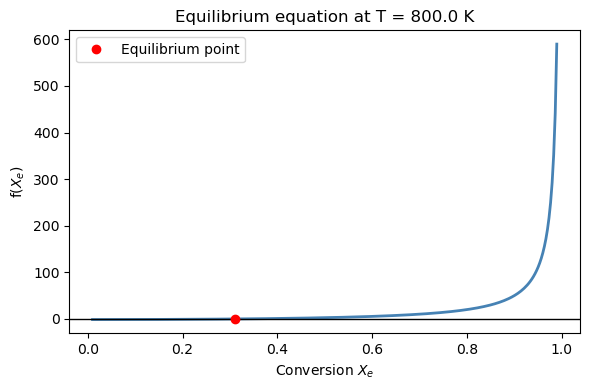

T = 800.0 K
Equilibrium conversion: X_e = 0.3109  (31.1%)
y_A = 0.5257,  y_B = 0.4743
Residual: -1.44e-14


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, fsolve

P = 3.0  # atm

def Keq(T):
    return TODO

def f_eq(X, T):
    return TODO

T_val = 800.0  # K

X_arr = np.linspace(0.01, 0.99, 300)

X_eq = TODO # Use brentq to solve f_eq(X, T_val) = 0 for X in (0, 1)
y_A  = TODO # 
y_B  = TODO # 


fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(X_arr, f_eq(X_arr, T_val), 'steelblue', linewidth=2)
ax.axhline(0, color='k', linewidth=1)
ax.set_xlabel('Conversion $X_e$'); ax.set_ylabel('f($X_e$)')
ax.set_title(f'Equilibrium equation at T = {T_val} K')
ax.plot(X_eq, 0, 'ro', label='Equilibrium point')
ax.legend()
plt.tight_layout(); plt.show()
print(f"T = {T_val} K")
print(f"Equilibrium conversion: X_e = {X_eq:.4f}  ({100*X_eq:.1f}%)")
print(f"y_A = {y_A:.4f},  y_B = {y_B:.4f}")
print(f"Residual: {f_eq(X_eq, T_val):.2e}")

**(b)** Compute and plot $X_e$ vs. $T$ for temperatures from 500 K to 1200 K. Does conversion increase or decrease with temperature? Is this consistent with Le Chatelier's principle for an endothermic reaction ($\Delta H > 0$)?

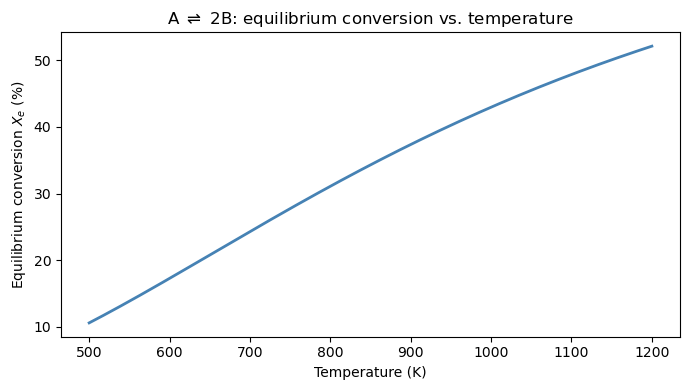

As T increases, X_e ...


In [ ]:
temps = np.linspace(500, 1200, 200)
X_eq_list = []

for T_val in temps:
    X_eq_list.append(TODO)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(temps, np.array(X_eq_list) * 100, 'steelblue', linewidth=2)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Equilibrium conversion $X_e$ (%)')
ax.set_title(r'A $\rightleftharpoons$ 2B: equilibrium conversion vs. temperature')
plt.tight_layout()
plt.show()

# Answer: does X_e increase or decrease with T?
print("As T increases, X_e ##TODO")

### Problem 2: Simultaneous Reaction and Energy Balance (`fsolve`)

A CSTR operates at steady state with the exothermic reaction $\text{A} \rightarrow \text{B}$. The mole and energy balances couple conversion $X$ and temperature $T$:

$$\text{Mole balance:} \quad \tau k(T)(1 - X) - X = 0$$

$$\text{Energy balance:} \quad X(-\Delta H_{rxn}) - \rho C_p (T - T_0) = 0$$

with parameters:
- $\tau = 100$ s (residence time)
- $k(T) = 10^6 \exp(-8000/T)$ s⁻¹ (Arrhenius rate constant)
- $\Delta H_{rxn} = -50{,}000$ J/mol (exothermic)
- $\rho C_p = 1000$ J/(L·K), $T_0 = 300$ K (feed temperature)

Solve for the steady-state conversion $X$ and temperature $T$.

**(a)** Define the system of equations and solve with `fsolve` using initial guess $X_0 = 0.5$, $T_0 = 350$ K. Print the solution and verify the residuals.

In [ ]:
import numpy as np
from scipy.optimize import fsolve

tau     = 100.0       # s
dHrxn   = -50000.0    # J/mol
rho_Cp  = 1000.0      # J/(L·K)
T_feed  = 300.0       # K

def k_arr(T):
    return TODO

def cstr_balances(vars):
    X, T = vars
    mole_balance   = TODO
    energy_balance = TODO
    return TODO

sol = TODO
X_ss, T_ss = sol

print(f"Steady-state conversion : X = {X_ss:.4f}  ({100*X_ss:.1f}%)")
print(f"Steady-state temperature: T = {T_ss:.2f} K")
print(f"Residuals: {cstr_balances(sol)}")

Steady-state conversion : X = 0.0003  (0.0%)
Steady-state temperature: T = 300.01 K
Residuals: [8.61940727125976e-18, -2.545696986544499e-11]


**(b)** Exothermic CSTRs can have multiple steady states. Try three different initial guesses and see if you find different solutions. Print the $(X, T)$ pair for each, and verify the residuals in all cases.

In [ ]:
guesses = [
    TODO,   # near low-conversion steady state (0.1, 310 K)
    TODO,   # intermediate guess (0.5, 350 K)
    TODO,   # near high-conversion steady state (0.9, 400 K)
]

print(f"{'Guess (X, T)':>20}  {'Solution X':>12}  {'Solution T (K)':>16}  {'Residuals':>20}")
print("-" * 76)
for x0 in guesses:
    sol = TODO
    res = TODO
    print(f"  ({x0[0]:.1f}, {x0[1]:.0f} K)       {sol[0]:>12.4f}  {sol[1]:>16.2f}  {res}")

        Guess (X, T)    Solution X    Solution T (K)             Residuals
----------------------------------------------------------------------------
  (0.1, 310 K)             0.0003            300.01  [-2.2183860651225906e-15, -2.7684521342052903e-11]
  (0.5, 350 K)             0.0003            300.01  [8.61940727125976e-18, -2.545696986544499e-11]
  (0.9, 400 K)             0.0003            300.01  [-9.188659653037307e-12, 1.729816290207964e-11]


In [1]:

import numpy as np
from scipy.optimize import fsolve

tau     = 100.0       # s
dHrxn   = -50000.0    # J/mol
rho_Cp  = 1000.0      # J/(L·K)
T_feed  = 300.0       # K

def k_arr(T):
    return 10**6 * np.exp(-8000.0/T) #TODO

def cstr_balances(vars):
    X, T = vars
    mole_balance   = tau * k_arr(T) * (1.0 - X) - X  #TODO
    energy_balance = X * (-dHrxn) - rho_Cp * (T - T_feed)  #TODO
    return [mole_balance, energy_balance]  #TODO

sol = fsolve(cstr_balances, x0 = [0.5, 350])  #TODO
X_ss, T_ss = sol

print(f"Steady-state conversion : X = {X_ss:.4f}  ({100*X_ss:.1f}%)")
print(f"Steady-state temperature: T = {T_ss:.2f} K")
print(f"Residuals: {cstr_balances(sol)}")

Steady-state conversion : X = 0.0003  (0.0%)
Steady-state temperature: T = 300.01 K
Residuals: [8.61940727125976e-18, -2.545696986544499e-11]
